# SSTADEX - Structured and Systematic Analog Design Exploration

SPDX-License-Identifier: Apache-2.0
</br>

#### Team Members 

|Name|Affiliation|IEEE Member|SSCS Member|
|:--:|:----------:|:----------:|:----------:|
| Daniel Arevalos (PhD Student) <br /> Email ID: daniel.arevalos@hm.edu|Hochschule Munchen| Yes |No|
| Dr. Stefan Wallentowitz (Profesor Advisor) <br /> Email ID: stefan.wallentowitz@hm.edu|Hochschule Munchen| Yes |Yes|

## Abstract

This notebook presents SSTADEX, a structured and systematic analog design exploration workflow for the implementation and evaluation of analog integrated circuits using open design infrastructures. Its purpose is to provide a practical and reproducible guide to the main stages of the flow, from device-level characterization and primitive construction to hierarchical exploration and circuit-level validation. Rather than serving as a purely theoretical description, the notebook is designed as an implementation-oriented companion that demonstrates how the methodology is applied in practice across analog building blocks of increasing complexity.

The notebook builds upon our previously published methodology for hierarchical and modular analog design automation, presented in Arévalos et al., A Topology-Independent and Scalable Methodology for Automated LDO Design Using Open PDKs [MDPI Electronics 14(17):3448](https://doi.org/10.3390/electronics14173448), and extends it into a more robust and hands-on SSTADEX workflow. The presented flow combines LUT-based transistor characterization, primitive-level abstraction, symbolic macromodeling, and specification-driven hierarchical exploration. These concepts are illustrated through a sequence of practical case studies, including the design of a one-stage OTA, a two-stage OTA, and an LDO.

## 1. Introduction

Analog integrated circuit design remains a highly knowledge-intensive task, often relying on repeated transistor-level simulation, manual iteration, and designer experience. While such an approach can produce high-performance circuits, it becomes increasingly difficult to scale across multiple topologies, technologies, and hierarchical design levels. In this context, methodologies that combine modularity, abstraction, and systematic exploration are especially valuable, since they can reduce design effort while preserving electrical interpretability.

SSTADEX addresses this problem through a structured and hierarchical workflow in which analog circuits are decomposed into reusable building blocks. Transistor-level primitives are characterized through Lookup Tables (LUTs), while larger functional blocks are represented as macromodels with simplified symbolic behavior and local specifications. This allows technology-aware device information, circuit-level constraints, and hierarchical refinement to coexist within the same design flow.

The purpose of this notebook is to present that workflow in a practical and reproducible way. Instead of focusing only on the methodology at a conceptual level, the notebook shows how the different elements of SSTADEX are constructed and applied in practice, from LUT generation and primitive definition to hierarchical circuit exploration and validation through representative case studies.

### 1.1 Background

SSTADEX combines two complementary perspectives: structured analog design and systematic design. In structured analog design, complex circuits are decomposed into a hierarchy of functional blocks rather than treated as monolithic transistor-level systems. This improves modularity, reuse, and interpretability. Systematic design complements this view by replacing purely manual tuning with explicit exploration and filtering procedures driven by device data and circuit specifications.

In SSTADEX, this combination is realized through LUT-based primitive characterization and symbolic macromodel-based abstraction. Primitive blocks provide technology-aware electrical behavior, while macromodels enable higher-level exploration, specification evaluation, and hierarchical refinement. Together, these elements support an efficient design workflow that remains closely tied to the electrical meaning of the circuit.

### 1.2 Notebook Overview

This notebook is organized as a progressive walkthrough of the SSTADEX workflow, moving from conceptual foundations to practical design examples of increasing complexity. It begins with the setup of the required tools and the installation of SSTADEX, followed by an introduction to the basic concepts of the flow through LUT generation and simple device-level visualizations.

The next sections focus on primitive construction and characterization, showing how reusable analog building blocks are implemented and explored within the framework. Once these foundations are established, the methodology is demonstrated through three case studies: the design of a one-stage OTA, the design of a two-stage OTA, and finally the design of an LDO. The notebook concludes with a summary of the main insights and lessons obtained from these examples.

### 1.3 Workflow at a Glance

At a high level, the SSTADEX workflow follows a hierarchical and specification-driven design process. The flow starts from transistor-level characterization and progressively moves toward higher abstraction levels, where primitives are assembled into macromodels and evaluated against circuit-level requirements.

The workflow can be summarized in the following steps:

1. Technology characterization through LUT generation.
2. Primitive definition and characterization.
3. Macromodel construction.
4. Specification and testbench definition.
5. Hierarchical exploration and filtering.
6. Parameter update and refinement across the hierarchy.
7. Validation through complete case studies.

The following sections implement these steps progressively, beginning with the preparation of the environment and continuing through primitives, hierarchical circuit design, and final validation.

## 2. Environment Setup and Tool Installation

This section prepares the execution environment required for the examples in this notebook. The setup includes the installation of system dependencies, creation of a Python environment, retrieval of the SSTADEX repository, installation of the required Python packages, and configuration of the IHP SG13G2 PDK together with ngspice support.

### 2.1 System Dependencies and Python Environment

The following commands install the system-level dependencies required by the notebook and create an isolated Python environment using `micromamba`.


In [1]:
import os
import pathlib
import sys

# Install system packages required for compilation and simulation
!apt update -y
!apt install -y time build-essential bison flex libx11-dev libreadline-dev libfftw3-dev libxcursor-dev libxaw7-dev libtool autoconf automake curl

# Install micromamba
!curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba

# Create isolated environment
conda_prefix_path = pathlib.Path("conda-env")
CONDA_PREFIX = str(conda_prefix_path.resolve())
%env CONDA_PREFIX={CONDA_PREFIX}

!mkdir -p {CONDA_PREFIX}/conda-meta
!echo 'python ==3.13*' >> {CONDA_PREFIX}/conda-meta/pinned

!bin/micromamba create --yes --prefix $CONDA_PREFIX
!bin/micromamba install --yes --prefix $CONDA_PREFIX --channel conda-forge python=3.13 pip svgutils

# Expose environment paths to the notebook session
site_package_path = conda_prefix_path / "lib/python3.13/site-packages"
sys.path.append(str(site_package_path.resolve()))

PATH = os.environ["PATH"]
%env PATH={PATH}:{CONDA_PREFIX}/bin

LD_LIBRARY_PATH = os.environ.get("LD_LIBRARY_PATH", "")
%env LD_LIBRARY_PATH={LD_LIBRARY_PATH}:{CONDA_PREFIX}/lib

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.7 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]3m
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease33m
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.0 MB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,311 kB]
Get:13 https://ppa.launchpadconten

### 2.2 Repository Setup and Python Package Installation

This step retrieves the SSTADEX repository and installs the Python packages required by the framework and its supporting modules.

In [2]:
# Clone the repository
!git clone -b exploration_fix https://github.com/lild4d4/SSTADEx.git --recursive

# Install Python packages from the repository
!$CONDA_PREFIX/bin/pip install ./SSTADEx
!$CONDA_PREFIX/bin/pip install ./SSTADEx/gmid


Cloning into 'SSTADEx'...
remote: Enumerating objects: 1340, done.
remote: Counting objects: 100% (446/446), done.
remote: Compressing objects: 100% (281/281), done.
remote: Total 1340 (delta 253), reused 323 (delta 141), pack-reused 894 (from 2)
Receiving objects: 100% (1340/1340), 127.08 MiB | 22.94 MiB/s, done.
Resolving deltas: 100% (688/688), done.
Updating files: 100% (378/378), done.
Submodule 'IHP-Open-PDK' (https://github.com/IHP-GmbH/IHP-Open-PDK.git) registered for path 'IHP-Open-PDK'
Submodule 'gmid' (https://github.com/lild4d4/gmid.git) registered for path 'gmid'
Cloning into '/content/SSTADEx/IHP-Open-PDK'...
remote: Enumerating objects: 19997, done.        
remote: Counting objects: 100% (3020/3020), done.        
remote: Compressing objects: 100% (398/398), done.        
remote: Total 19997 (delta 2843), reused 2622 (delta 2622), pack-reused 16977 (from 2)        
Receiving objects: 100% (19997/19997), 414.24 MiB | 21.17 MiB/s, done.
Resolving deltas: 100% (13096/13096)

### 2.3 OpenVAF, PDK, and ngspice Configuration

The final setup step configures the PDK, installs the OpenVAF binary, compiles ngspice support for the selected process (may take a while sorry but needed the osdi support), and links the required `.spiceinit` file.

In [3]:
# Set PDK-related environment variables
%env PDK_ROOT=/content/SSTADEx/IHP-Open-PDK
%env PDK=ihp-sg13g2

PDK_ROOT = os.environ["PDK_ROOT"]
PDK = os.environ["PDK"]

# Install OpenVAF
!mkdir -p bin
!curl -Ls https://openva.fra1.cdn.digitaloceanspaces.com/openvaf_23_5_0_linux_amd64.tar.gz | tar -xzv -C bin
!chmod +x ./bin/openvaf

os.environ["PATH"] = os.environ["PATH"] + ":" + os.path.abspath("./bin")
!which openvaf

# Build ngspice
!git clone git://git.code.sf.net/p/ngspice/ngspice
!cd ngspice && ./compile_linux.sh

# Install ngspice support from the selected PDK
!python3 SSTADEx/IHP-Open-PDK/ihp-sg13g2/libs.tech/ngspice/install.py

# Link local spice initialization file
!ln -sf /content/SSTADEx/IHP-Open-PDK/ihp-sg13g2/libs.tech/ngspice/.spiceinit ~/.spiceinit
!ls -l ~/.spiceinit


env: PDK_ROOT=/content/SSTADEx/IHP-Open-PDK
env: PDK=ihp-sg13g2


openvaf
/content/bin/openvaf
Cloning into 'ngspice'...
remote: Enumerating objects: 140022, done.
remote: Counting objects: 100% (140022/140022), done.
remote: Compressing objects: 100% (27541/27541), done.
remote: Total 140022 (delta 113860), reused 136531 (delta 111124), pack-reused 0 (from 0)
Receiving objects: 100% (140022/140022), 45.95 MiB | 17.28 MiB/s, done.
Resolving deltas: 100% (113860/113860), done.
Removing files to be remade
Running libtoolize
libtoolize: putting auxiliary files in '.'.
libtoolize: copying file './ltmain.sh'
libtoolize: putting macros in AC_CONFIG_MACRO_DIRS, 'm4'.
libtoolize: copying file 'm4/libtool.m4'
libtoolize: copying file 'm4/ltoptions.m4'
libtoolize: copying file 'm4/ltsugar.m4'
libtoolize: copying file 'm4/ltversion.m4'
libtoolize: copying file 'm4/lt~obsolete.m4'
Running aclocal 
Running autoheader
Running automake -Wall --copy --add-missing
configure.ac:46: installing './ar-lib'
configure.ac:42: installing './compile'
configure.ac:44: installi

## 3. SSTADEX Basics

### LUTs generation

In [4]:
from mosplot.lookup_table_generator.simulators import NgspiceSimulator
from mosplot.lookup_table_generator import TransistorSweep, LookupTableGenerator
import os
from pathlib import Path

PDK_ROOT=os.environ['PDK_ROOT']
PDK=os.environ['PDK']

ngspice_nmos = NgspiceSimulator(
    simulator_path="ngspice",       
    temperature=27,                
    lib_mappings = [(PDK_ROOT+'/'+PDK+"/libs.tech/ngspice/models/cornerMOSlv.lib", "mos_tt")],
    osdi_paths = [(PDK_ROOT+'/'+PDK+"/libs.tech/ngspice/osdi/psp103_nqs.osdi")],
    mos_spice_symbols = ("XM1", "n.xm1.nsg13_lv_nmos"),
    device_parameters = {"w": 5e-6,}
)
ngspice_pmos = NgspiceSimulator(
    simulator_path="ngspice",       
    temperature=27,                 
    lib_mappings = [(PDK_ROOT+'/'+PDK+"/libs.tech/ngspice/models/cornerMOSlv.lib", "mos_tt")],
    osdi_paths = [(PDK_ROOT+'/'+PDK+"/libs.tech/ngspice/osdi/psp103_nqs.osdi")],
    mos_spice_symbols = ("XM1", "n.xm1.nsg13_lv_pmos"),
    device_parameters = {"w": 5e-6,}
)

# Define a sweep object for NMOS transistors.
nmos_sweep = TransistorSweep(
    mos_type="sg13_lv_nmos",
    vgs=(0.1, 1.2, 0.01),
    vds=(0.1, 1.2, 0.01),
    vbs=(0, -1.0, -0.1),
    length=[0.4e-6, 0.8e-6, 1.6e-6, 3.2e-6, 6.4e-6]
)
# Define a sweep object for PMOS transistors.
pmos_sweep = TransistorSweep(
    mos_type="sg13_lv_pmos",
    vgs=(-0.1, -1.2, -0.01),
    vds=(-0.1, -1.2, -0.01),
    vbs=(0, 1.0, 0.1),
    length=[0.4e-6, 0.8e-6, 1.6e-6, 3.2e-6, 6.4e-6]
)

obj_nmos = LookupTableGenerator(
    description="OpenPDK ihp-sg13g2",
    simulator=ngspice_nmos,
    model_sweeps={"sg13_lv_nmos": nmos_sweep},
    n_process=1,
)
obj_pmos = LookupTableGenerator(
    description="OpenPDK ihp-sg13g2",
    simulator=ngspice_pmos,
    model_sweeps={"sg13_lv_pmos": pmos_sweep},
    n_process=1,
)

SSTADEX = Path("./SSTADEx").resolve()
obj_nmos.build(str(SSTADEX / "LUTs/ihp-sg13g2/lv_5w_nmos"))
obj_pmos.build(str(SSTADEX / "LUTs/ihp-sg13g2/lv_5w_pmos"))


----- Sample Netlist -----
* Lookup Table Generation *
.lib '/content/SSTADEx/IHP-Open-PDK/ihp-sg13g2/libs.tech/ngspice/models/cornerMOSlv.lib' mos_tt
VGS NG 0 DC=0
VBS NB 0 DC=0.0
VDS ND 0 DC=0
XM1 ND NG 0 NB sg13_lv_nmos l=4e-07 w=5e-06
.options TEMP = 27
.options TNOM = 27
.control
pre_osdi /content/SSTADEx/IHP-Open-PDK/ihp-sg13g2/libs.tech/ngspice/osdi/psp103_nqs.osdi
save i(vds)
save @n.xm1.nsg13_lv_nmos[weff]
save @n.xm1.nsg13_lv_nmos[vth]
save @n.xm1.nsg13_lv_nmos[vdsat]
save @n.xm1.nsg13_lv_nmos[vdssat]
save @n.xm1.nsg13_lv_nmos[gm]
save @n.xm1.nsg13_lv_nmos[gmbs]
save @n.xm1.nsg13_lv_nmos[gds]
save @n.xm1.nsg13_lv_nmos[cgg]
save @n.xm1.nsg13_lv_nmos[cgs]
save @n.xm1.nsg13_lv_nmos[cgd]
save @n.xm1.nsg13_lv_nmos[cdd]
dc VDS 0.1 1.2 0.01 VGS 0.1 1.2 0.01
let i_vds = abs(i(vds))
write output all
.endc
.end
--------------------------
Total simulation jobs: 55


Progress: 1/55 jobs completed
Progress: 2/55 jobs completed
Progress: 3/55 jobs completed
Progress: 4/55 jobs completed
Progress: 5/55 jobs completed
Progress: 6/55 jobs completed
Progress: 7/55 jobs completed
Progress: 8/55 jobs completed
Progress: 9/55 jobs completed
Progress: 10/55 jobs completed
Progress: 11/55 jobs completed
Progress: 12/55 jobs completed
Progress: 13/55 jobs completed
Progress: 14/55 jobs completed
Progress: 15/55 jobs completed
Progress: 16/55 jobs completed
Progress: 17/55 jobs completed
Progress: 18/55 jobs completed
Progress: 19/55 jobs completed
Progress: 20/55 jobs completed
Progress: 21/55 jobs completed
Progress: 22/55 jobs completed
Progress: 23/55 jobs completed
Progress: 24/55 jobs completed
Progress: 25/55 jobs completed
Progress: 26/55 jobs completed
Progress: 27/55 jobs completed
Progress: 28/55 jobs completed
Progress: 29/55 jobs completed
Progress: 30/55 jobs completed
Progress: 31/55 jobs completed
Progress: 32/55 jobs completed
Progress: 33/55 j

## 4. One-Stage OTA Design

![alt text](figures/One-Stage-Diagram.png "Diagram")
![alt text](figures/One-Stage-Hierarchy.png "Hierarchy")

### 4.1 Imports

In [5]:
import pandas as pd
from pathlib import Path
import sys
import numpy as np
from sympy import Symbol
from sympy import lambdify
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
sns.color_palette("mako")

from sstadex import Macromodel, Test, dfs, Testbench, VoltageSource, CurrentSource, Resistor, Capacitor

SSTADEX = Path("./SSTADEx").resolve()
if str(SSTADEX) not in sys.path:
    sys.path.insert(0, str(SSTADEX))

from sstadex.models import Library

N_points = 10
lib = Library(
    name      = "ihp_sg13g2",
    lut_files = {
        "nmos": str(SSTADEX / "LUTs/ihp-sg13g2/lv_5w_nmos.npz"),
        "pmos": str(SSTADEX / "LUTs/ihp-sg13g2/lv_5w_pmos.npz"),
    },
)

lib.register_all(SSTADEX / "analoglib/primitives/")
print(lib)

[Library:ihp_sg13g2] registered 'simplecommonsource' <- /content/SSTADEx/analoglib/primitives/simplecommonsource
[Library:ihp_sg13g2] registered 'simplecurrentmirror' <- /content/SSTADEx/analoglib/primitives/simplecurrentmirror
[Library:ihp_sg13g2] registered 'simplecurrentsource' <- /content/SSTADEx/analoglib/primitives/simplecurrentsource
[Library:ihp_sg13g2] registered 'simplediffpair' <- /content/SSTADEx/analoglib/primitives/simplediffpair
<Library 'ihp_sg13g2': ['simplecommonsource', 'simplecurrentmirror', 'simplecurrentsource', 'simplediffpair']>


/content/conda-env/lib/python3.13/site-packages/sstadex/spice_sim/spice_sim.py:140: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(SPICE_DIR + "temp.csv", sep="\s+")


### 4.2 Specifications Definition

In [6]:
## Electrical parameters
Vout = 1
Vref = 0.9                                       
Vdd = 1.5                           
CL = 1e-12 
## OTA specifications
gain_condition = 30
estability_condition = 60
size_condition = 1e-3

I_bias_ref = 20e-6
I_amp = 20e-6 

lengths = [4e-7, 8e-7, 1.6e-6, 3.2e-6, 6.4e-6]

### 4.3 Primitives Definition

In [7]:
vs = np.linspace(0.2, Vout-0.1, N_points)

diffpair = lib.get("simplediffpair", il=I_amp)
currentmirror = lib.get("simplecurrentmirror", il=I_amp)
currentsource = lib.get('simplecurrentsource', il=I_amp)

diffpair.set_port_voltages({"VINP": Vref, "VINN": Vref, "VOUTP": Vout, "VOUTN": Vout, "VTAIL": vs})
currentmirror.set_port_voltages({"VINP": Vout, "VINN": Vout, "VOUTP": Vout, "VOUTN": Vout, "VDD": Vdd})
currentsource.set_port_voltages({"VOUTP": vs, "VSS": 0, "VINP": vs})

print(diffpair.summary())
print(currentmirror.summary())
print(currentsource.summary())

diffpair_df = diffpair.build()
currentmirror_df = currentmirror.build()
currentsource_df = currentsource.build(ref_current=I_amp)

diffpair_df.to_csv('diffpair.csv')
currentmirror_df.to_csv('currentmirror.csv')
currentsource_df.to_csv('currentsource.csv')

diffpair.parameters = {Symbol('g_gm_xdp_m1'): diffpair_df['gm'].values, Symbol('R_gds_xdp_m1'): diffpair_df['Ro'].values}
currentmirror.parameters = {Symbol('g_gm_xcm_m1'): currentmirror_df['gm'].values, Symbol('R_gds_xcm_m1'): currentmirror_df['Ro'].values}
currentsource.parameters = {Symbol('g_gm_cs_m1'): currentsource_df['gm'].values, Symbol('R_gds_cs_m1'): currentsource_df['Ro'].values}

diffpair.outputs = {Symbol("W_diff"): diffpair_df["width"].values, Symbol("L_diff"): diffpair_df["length"].values}
currentmirror.outputs = {Symbol("W_al"): currentmirror_df["width"].values, Symbol("L_al"): currentmirror_df["length"].values}
currentsource.outputs = {Symbol("W_cs_m1"): currentsource_df["width_m1"].values, Symbol("W_cs_m2"): currentsource_df["width_m2"].values, Symbol("L_cs"): currentsource_df["length"].values}

Primitive : simplediffpair  (v1.0)
Desc      : Simple differential pair — single transistor per branch, NMOS or PMOS
────────────────────────────────────────────────────────────
Ports:
  Port('VINP', INPUT, 0.9V)
  Port('VINN', INPUT, 0.9V)
  Port('VOUTP', OUTPUT, 1V)
  Port('VOUTN', OUTPUT, 1V)
  Port('VTAIL', BIAS, [0.2        0.27777778 0.35555556 0.43333333 0.51111111 0.58888889
 0.66666667 0.74444444 0.82222222 0.9       ]V)
Layout params:
Primitive : simplecurrentmirror  (v1.0)
Desc      : Simple current mirror — single transistor per branch, NMOS or PMOS
────────────────────────────────────────────────────────────
Ports:
  Port('VINP', INPUT, 1V)
  Port('VINN', INPUT, 1V)
  Port('VOUTP', OUTPUT, 1V)
  Port('VOUTN', OUTPUT, 1V)
  Port('VDD', BIAS, 1.5V)
Layout params:
Primitive : simplecurrentsource  (v1.0)
Desc      : Simple NMOS current source — single transistor per branch
────────────────────────────────────────────────────────────
Ports:
  Port('VINP', INPUT, [0.2        0.2

### 4.4 Macromodels Definition

In [8]:
OTA_1stage_macro = Macromodel(
    name = 'OTA_1stage_macro',
    ports=["VINP", "VINN", "VOUT", "VDD", "IBIAS", "Vbias", "VSS"],
    electrical_parameters = {"Vdd": Vdd, "Vneg": Vref, "Vout": Vout, "Il": I_amp},
    outputs = [Symbol("W_diff"), Symbol("L_diff"),Symbol("W_al"), Symbol("L_al")],
    macromodel_parameters={Symbol('Ra'): np.logspace(3, 7, N_points), Symbol('gma'): np.logspace(-5, -2, N_points)}
    )

current_source_macro = Macromodel(
    name = 'current_source_macro',
    ports = ['VOUT', 'VSS', 'Vbias'],
    electrical_parameters = {'Iref': I_bias_ref, 'Ibias': I_amp, 'Vdd': Vdd},
    outputs = [Symbol("W_cs_m1"), Symbol("W_cs_m2"), Symbol("L_cs"),
    ],
    model="""I{INSTANCE} {VOUT} {VSS} 0""",
    macromodel_parameters = {Symbol('Ixcs_macro'): [I_amp]}
)

### 4.5 Building the Hierarchy: Interface variables, Shared Nodes and Instances

In [9]:

diffpair.interface_variables={'vs_diff': np.tile(vs, len(lengths))}
currentsource.interface_variables={'vs_cs': np.tile(vs, len(lengths)),}

OTA_1stage_macro.interface_variables = ["vs_diff"]
current_source_macro.interface_variables=["vs_cs"]

OTA_1stage_macro.shared_nodes = {"IBIAS_node": ["vs_diff", "vs_cs"]}

In [10]:
OTA_1stage_macro.add_instance(
    "xdp",
    diffpair,
    {"VINP": "VINP", "VINN": "VINN", "VOUTP": "VOUT", "VOUTN": "N1", "VTAIL": "IBIAS"},
    index=0,
    netlist_params={"W_diff": Symbol("W_diff"), "L_diff": Symbol("L_diff"), "ng_diff": Symbol("ng_diff")},
)

OTA_1stage_macro.add_instance(
    "xcm",
    currentmirror,
    {"VINP": "N1", "VINN": "N1", "VOUTP": "VOUT", "VOUTN": "N1", "VDD": "VDD"},
    index=0,
    netlist_params={"W_al": Symbol("W_al"), "L_al": Symbol("L_al"), "ng_al": Symbol("ng_al")},
)

OTA_1stage_macro.add_instance(
    "xcs_macro",
    current_source_macro,
    {"VOUT": "IBIAS", "VSS": "VSS", "Vbias": "Vbias"},
    index=0,
    netlist_params={'Ibias': Symbol('Ibias')}
)

current_source_macro.add_instance(
    "xcs",
    currentsource,
    {"VOUTP": "VOUT", "VSS": "VSS", "VOUTN": "Vbias", "VINP": "Vbias", "VINN": "Vbias"},
    index=0,
    netlist_params={"W_cs_m1": Symbol("W_cs_m1"), "W_cs_m2": Symbol("W_cs_m2"), "L_cs": Symbol("L_cs"), "ng_cs_m1": Symbol("ng_cs_m1"), "ng_cs_m2": Symbol("ng_cs_m2")}
)

### 4.6 Conditions and Propagation Definition

In [11]:
OTA_1stage_macro.propagated_conditions = {
    "direct": [
        {
            "kind": "range",
            "column": Symbol("W_al"),
            "condition": {"min": 1e-6, "max": 1000e-6},
        },
        {
            "kind": "range",
            "column": Symbol("W_diff"),
            "condition": {"min": 1e-6, "max": 1000e-6},
        },
    ],
    "derived": [],
}

current_source_macro.propagated_conditions = {
    "direct": [
        {
            "kind": "range",
            "column": Symbol("W_cs_m1"),
            "condition": {"min": 1e-6, "max": 1000e-6},
        },
        {
            "kind": "range",
            "column": Symbol("W_cs_m2"),
            "condition": {"min": 1e-6, "max": 1000e-6},
        },
    ],
    "derived": [],
}

### 4.7 Testbenches

In [12]:
tb_gain = Testbench(
    name="ota_1stage_gain",
    dut=OTA_1stage_macro,
    view="small_signal",
    elements=[
        VoltageSource("Vdd", "VDD", "VSS", 0),
        VoltageSource("Vss", "VSS", "VSS", 0),
        VoltageSource("V_n", "VINN", "VSS", 0),
        VoltageSource("V_p", "VINP", "VSS", 1),
    ],
    tf=("VOUT", "VINP"),
    parameter_map={
        Symbol("Vdd"): 0,
        Symbol("Vss"): 0,
        Symbol("V_n"): 0,
        Symbol("V_p"): 1,
        Symbol("g_gm_xdp_m2"): Symbol("g_gm_xdp_m1"),
        Symbol("R_gds_xdp_m2"): Symbol("R_gds_xdp_m1"),
        Symbol("g_gm_xcm_m2"): Symbol("g_gm_xcm_m1"),
        Symbol("R_gds_xcm_m2"): Symbol("R_gds_xcm_m1"),
        Symbol("s"): 0,
    },
)

gain_1stage = tb_gain.make_test(
    name="gain_1stage",
    opt_goal="max",
    conditions={"min": [10 ** (-100 / 20)]},
)

tb_rout = Testbench(
    name="ota_1stage_rout",
    dut=OTA_1stage_macro,
    view="small_signal",
    elements=[
        VoltageSource("Vdd", "VDD", "VSS", 0),
        VoltageSource("Vss", "VSS", "VSS", 0),
        VoltageSource("V_n", "VINN", "VSS", 0),
        VoltageSource("V_p", "VINP", "VSS", 0),
        VoltageSource("Vr", "VR", "VSS", 1),
        Resistor("Rr", "VR", "VOUT", 1000),
    ],
    tf=("VOUT", "VR"),
    parameter_map={
        Symbol("Vdd"): 0,
        Symbol("Vss"): 0,
        Symbol("V_n"): 0,
        Symbol("V_p"): 0,
        Symbol("Vr"): 1,
        Symbol("Rr"): 1000,
        Symbol("g_gm_xdp_m2"): Symbol("g_gm_xdp_m1"),
        Symbol("R_gds_xdp_m2"): Symbol("R_gds_xdp_m1"),
        Symbol("g_gm_xcm_m2"): Symbol("g_gm_xcm_m1"),
        Symbol("R_gds_xcm_m2"): Symbol("R_gds_xcm_m1"),
        Symbol("s"): 0,
    },
)

rout_1stage = tb_rout.make_test(
    name="rout_1stage",
    opt_goal="max",
    target_param=Symbol("Ra"),
    conditions={"min": [1]},
    lamd=lambda x: x * 1000 / (1 - x),
)

tb_gm_1stage = Testbench(
    name="ota_1stage_gm",
    dut=OTA_1stage_macro,
    tf=("VOUT", "VINP"),
)

gm_1stage = tb_gm_1stage.make_test(
    name="gm_1stage",
    opt_goal="max",
    target_param=Symbol("ga"),
    composed=1,
    out_def = {"divide": [gain_1stage, rout_1stage]},
    conditions={"min": [1e-10]},
)

tb_ibias = Testbench(
    name="currentsource_ibas",
    dut=current_source_macro,
    view="small_signal",
    elements=[
        VoltageSource("Vdd", "VDD", "VSS", 0),
        VoltageSource("Vss", "VSS", "VSS", 0),
        CurrentSource("I0", "Vbias", "VSS", 0),
    ],
    tf=("VOUT", "Vbias"),
    parameter_map={
        Symbol("Vdd"): 0,
        Symbol("Vss"): 0,
        Symbol("I0"): 0,
        Symbol("s"): 0,
        Symbol('g_gm_cs_m2'): Symbol('g_gm_cs_m1'),
        Symbol('R_gds_cs_m2'): Symbol('R_gds_cs_m1')
    }
)

ibias_currentsource = tb_ibias.make_test(
    name="ibias_currentsource",
    opt_goal="max",
    conditions={"min": [0]},
)

### 4.8 Building

In [13]:
from pathlib import Path

osdi_dir = Path("output")
osdi_dir.mkdir(parents=True, exist_ok=True)

current_source_macro.specifications=[ibias_currentsource]
current_source_macro.primitives = [currentsource]
current_source_macro.num_level_exp = 1
current_source_macro.run_pareto = False

OTA_1stage_macro.specifications = [gain_1stage, rout_1stage, gm_1stage]
OTA_1stage_macro.opt_specifications = [gain_1stage]
OTA_1stage_macro.primitives = [diffpair, currentmirror]
OTA_1stage_macro.submacromodels = [current_source_macro]
OTA_1stage_macro.num_level_exp = -1
OTA_1stage_macro.is_primitive = 0
OTA_1stage_macro.run_pareto = False

_, _, _, ota_1stage_df, mask = dfs(OTA_1stage_macro, debug = False)

ota_1stage_df.to_csv('ota_1stage_df.csv')

############################################
Starting the exploration of:  OTA_1stage_macro
DEBUG MESSAGE
{'VOUT': 'IBIAS', 'VSS': 'VSS', 'Vbias': 'Vbias'}
DEBUG MESSAGE
{'VOUT': 'IBIAS', 'VSS': 'VSS', 'Vbias': 'Vbias'}
* Small-signal netlist for ota_1stage_gain
* instance xdp (simplediffpair)
R_gds_xdp_m1 VOUT IBIAS 1
G_gm_xdp_m1 VOUT IBIAS VINP IBIAS 1
R_gds_xdp_m2 N1 IBIAS 1
G_gm_xdp_m2 N1 IBIAS VINN IBIAS 1
* instance xcm (simplecurrentmirror)
R_gds_xcm_m1 VOUT VDD 1
G_gm_xcm_m1 VOUT VDD N1 VDD 1
R_gds_xcm_m2 N1 VDD 1
G_gm_xcm_m2 N1 VDD N1 VDD 1
* instance xcs_macro (current_source_macro)
Ixcs_macro IBIAS VSS 0
Vdd VDD VSS 0
Vss VSS VSS 0
V_n VINN VSS 0
V_p VINP VSS 1

Netlist:  ota_1stage_gain
Running MNA... 
MNA of gain_1stage took: 0.23341631889343262
MNA nodes:     VOUT  IBIAS  VINP  N1  VINN  VDD  VSS
0     1      2     3   4     5    6    7
MNA solution:  {I_V_n: 0, I_V_p: 0, I_Vdd: -Ixcs_macro, I_Vss: 0, v1: (Ixcs_macro*R_gds_xcm_m1*R_gds_xcm_m2*R_gds_xdp_m1*R_gds_xdp_m2*g_g

In [14]:
OTA_1stage_macro.run_pareto = True

_, _, _, ota_1stage_df_pareto, mask = dfs(OTA_1stage_macro, debug = False)

ota_1stage_df_pareto.to_csv('ota_1stage_df_pareto.csv')

############################################
Starting the exploration of:  ota_1stage_rout
DEBUG MESSAGE
{'VOUT': 'IBIAS', 'VSS': 'VSS', 'Vbias': 'Vbias'}
DEBUG MESSAGE
{'VOUT': 'IBIAS', 'VSS': 'VSS', 'Vbias': 'Vbias'}
* Small-signal netlist for ota_1stage_gain
* instance xdp (simplediffpair)
R_gds_xdp_m1 VOUT IBIAS 1
G_gm_xdp_m1 VOUT IBIAS VINP IBIAS 1
R_gds_xdp_m2 N1 IBIAS 1
G_gm_xdp_m2 N1 IBIAS VINN IBIAS 1
* instance xcm (simplecurrentmirror)
R_gds_xcm_m1 VOUT VDD 1
G_gm_xcm_m1 VOUT VDD N1 VDD 1
R_gds_xcm_m2 N1 VDD 1
G_gm_xcm_m2 N1 VDD N1 VDD 1
* instance xcs_macro (currentsource_ibas)
Ixcs_macro IBIAS VSS 0
Vdd VDD VSS 0
Vss VSS VSS 0
V_n VINN VSS 0
V_p VINP VSS 1

Netlist:  ota_1stage_gain
Running MNA... 


MNA of gain_1stage took: 0.03600883483886719
MNA nodes:     VOUT  IBIAS  VINP  N1  VINN  VDD  VSS
0     1      2     3   4     5    6    7
MNA solution:  {I_V_n: 0, I_V_p: 0, I_Vdd: -Ixcs_macro, I_Vss: 0, v1: (Ixcs_macro*R_gds_xcm_m1*R_gds_xcm_m2*R_gds_xdp_m1*R_gds_xdp_m2*g_gm_xcm_m1*g_gm_xdp_m2 - Ixcs_macro*R_gds_xcm_m1*R_gds_xcm_m2*R_gds_xdp_m1*R_gds_xdp_m2*g_gm_xcm_m2*g_gm_xdp_m1 + Ixcs_macro*R_gds_xcm_m1*R_gds_xcm_m2*R_gds_xdp_m1*g_gm_xcm_m1 - Ixcs_macro*R_gds_xcm_m1*R_gds_xcm_m2*R_gds_xdp_m1*g_gm_xdp_m1 - Ixcs_macro*R_gds_xcm_m1*R_gds_xcm_m2*R_gds_xdp_m2*g_gm_xcm_m2 - Ixcs_macro*R_gds_xcm_m1*R_gds_xcm_m2 - Ixcs_macro*R_gds_xcm_m1*R_gds_xdp_m1*R_gds_xdp_m2*g_gm_xdp_m1 - Ixcs_macro*R_gds_xcm_m1*R_gds_xdp_m2 + R_gds_xcm_m1*R_gds_xcm_m2*R_gds_xdp_m1*R_gds_xdp_m2*V_n*g_gm_xcm_m1*g_gm_xdp_m1*g_gm_xdp_m2 + R_gds_xcm_m1*R_gds_xcm_m2*R_gds_xdp_m1*R_gds_xdp_m2*V_n*g_gm_xcm_m2*g_gm_xdp_m1*g_gm_xdp_m2 - R_gds_xcm_m1*R_gds_xcm_m2*R_gds_xdp_m1*R_gds_xdp_m2*V_p*g_gm_xcm_m1*g_gm_xdp_m1*g_gm_xdp_m

In [15]:
ota_1stage_df

,Ixcs_macro,g_gm_xdp_m1,R_gds_xdp_m1,g_gm_xcm_m1,R_gds_xcm_m1,gain_1stage,rout_1stage,gm_1stage,W_cs_m1,W_cs_m2,L_cs,vs_cs,W_diff,L_diff,vs_diff,W_al,L_al,area
700,0.00002,0.00013,169420.659441,0.000118,5.586895e+05,16.901232,122876.275414,0.000138,0.000001,0.000001,8.000000e-07,0.511111,0.000002,4.000000e-07,0.511111,0.000005,4.000000e-07,0.000011
701,0.00002,0.00013,169420.659441,0.000112,9.374181e+05,18.702639,135194.693861,0.000138,0.000001,0.000001,8.000000e-07,0.511111,0.000002,4.000000e-07,0.511111,0.000008,8.000000e-07,0.000014
702,0.00002,0.00013,169420.659441,0.000109,1.504682e+06,19.878795,143225.460644,0.000139,0.000001,0.000001,8.000000e-07,0.511111,0.000002,4.000000e-07,0.511111,0.000014,1.600000e-06,0.000022
703,0.00002,0.00013,169420.659441,0.000108,2.383569e+06,20.669606,148650.870937,0.000139,0.000001,0.000001,8.000000e-07,0.511111,0.000002,4.000000e-07,0.511111,0.000028,3.200000e-06,0.000037
704,0.00002,0.00013,169420.659441,0.000107,3.742880e+06,21.193126,152262.370133,0.000139,0.000001,0.000001,8.000000e-07,0.511111,0.000002,4.000000e-07,0.511111,0.000055,6.400000e-06,0.000067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6585,0.00002,0.00028,153663.815578,0.000118,5.586895e+05,33.617584,114188.249547,0.000294,0.000002,0.000002,6.400000e-06,0.744444,0.000509,6.400000e-06,0.744444,0.000005,4.000000e-07,0.000532
6586,0.00002,0.00028,153663.815578,0.000112,9.374181e+05,36.925668,124709.745190,0.000296,0.000002,0.000002,6.400000e-06,0.744444,0.000509,6.400000e-06,0.744444,0.000008,8.000000e-07,0.000536
6587,0.00002,0.00028,153663.815578,0.000109,1.504682e+06,39.059846,131484.586491,0.000297,0.000002,0.000002,6.400000e-06,0.744444,0.000509,6.400000e-06,0.744444,0.000014,1.600000e-06,0.000543
6588,0.00002,0.00028,153663.815578,0.000108,2.383569e+06,40.483777,136025.563027,0.000298,0.000002,0.000002,6.400000e-06,0.744444,0.000509,6.400000e-06,0.744444,0.000028,3.200000e-06,0.000558


### 4.9 Exploration Results

In [16]:
ota_1stage_df["gain"] = 20*np.log10(ota_1stage_df["gain_1stage"])
ota_1stage_df_pareto["gain"] = 20*np.log10(ota_1stage_df_pareto["gain_1stage"])
ota_1stage_df["bw"] = 1/(2*np.pi*ota_1stage_df["rout_1stage"]*CL)
ota_1stage_df_pareto["bw"] = 1/(2*np.pi*ota_1stage_df_pareto["rout_1stage"]*CL)

/tmp/ipykernel_9427/1367401075.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(ax=axs[0,1], data=ota_1stage_df, x="area", y="bw", palette='flare')
/tmp/ipykernel_9427/1367401075.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(ax=axs[1,0], data=ota_1stage_df, x="area", y="gm_1stage", palette='flare')


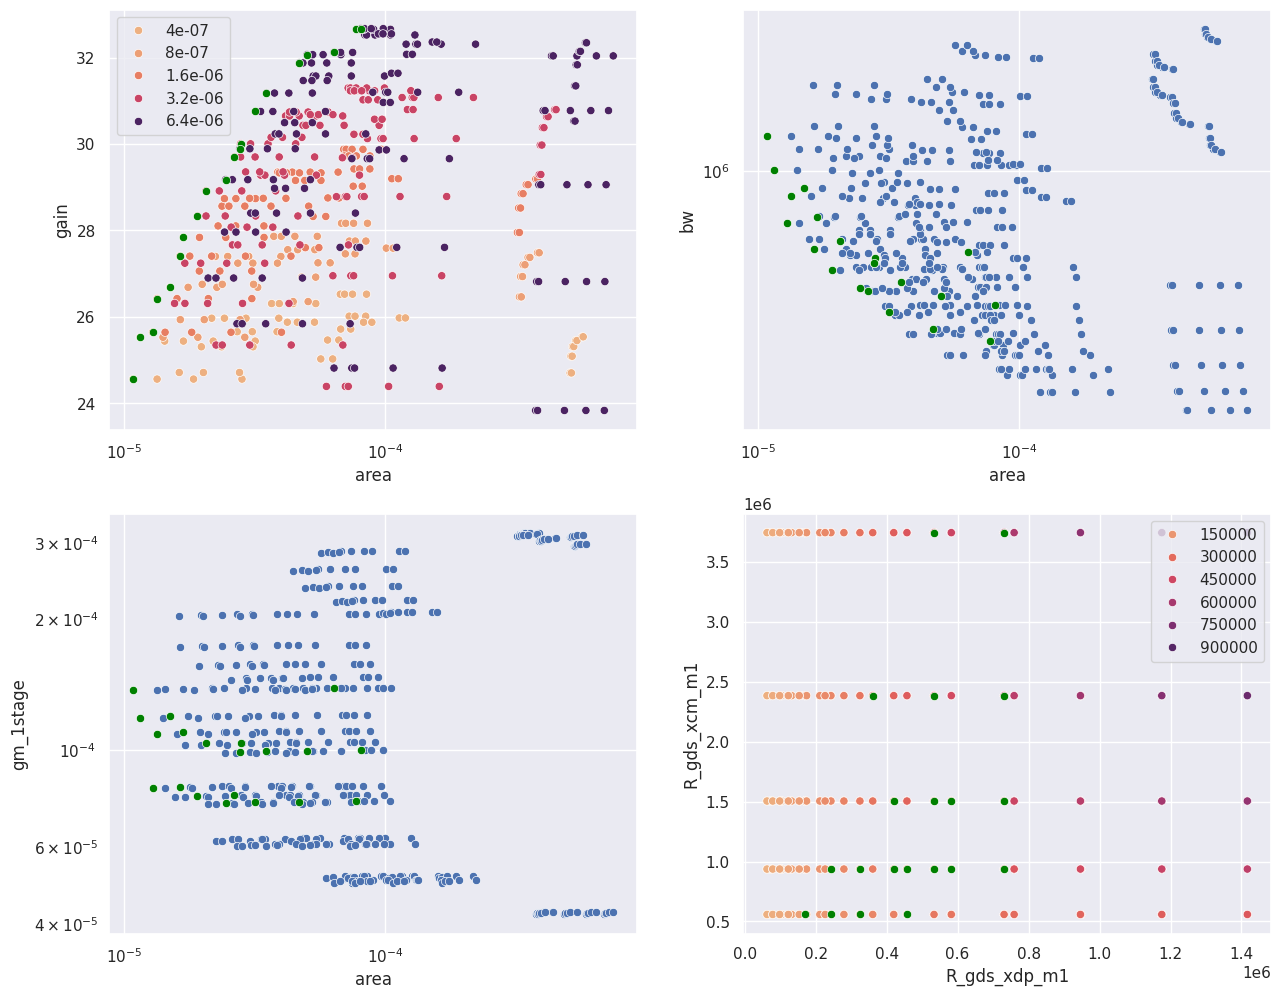

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
sns.scatterplot(ax=axs[0,0], data=ota_1stage_df, x="area", y="gain", hue=Symbol("L_diff"), palette='flare')
sns.scatterplot(ax=axs[0,0], data=ota_1stage_df_pareto, x='area', y='gain', c='green')
sns.scatterplot(ax=axs[0,1], data=ota_1stage_df, x="area", y="bw", palette='flare')
sns.scatterplot(ax=axs[0,1], data=ota_1stage_df_pareto, x='area', y='bw', c='green')
sns.scatterplot(ax=axs[1,0], data=ota_1stage_df, x="area", y="gm_1stage", palette='flare')
sns.scatterplot(ax=axs[1,0], data=ota_1stage_df_pareto, x='area', y='gm_1stage', c='green')
sns.scatterplot(ax=axs[1,1], data=ota_1stage_df, x=Symbol("R_gds_xdp_m1"), y=Symbol("R_gds_xcm_m1"), hue="rout_1stage", palette='flare')
sns.scatterplot(ax=axs[1,1], data=ota_1stage_df_pareto, x=Symbol("R_gds_xdp_m1"), y=Symbol("R_gds_xcm_m1"), c='green')

axs[0,0].set_xscale('log')

axs[0,1].set_xscale('log')
axs[0,1].set_yscale('log')

axs[1,0].set_xscale('log')
axs[1,0].set_yscale('log')

### 4.10 Verification

In [18]:
wmax = 5e-6

ng_diff = np.ceil(ota_1stage_df_pareto[Symbol("W_diff")].to_numpy() / wmax).astype(int)
ng_al = np.ceil(ota_1stage_df_pareto[Symbol("W_al")].to_numpy() / wmax).astype(int)
ng_cs_m1 = np.ceil(ota_1stage_df_pareto[Symbol("W_cs_m1")].to_numpy() / wmax).astype(int)
ng_cs_m2 = np.ceil(ota_1stage_df_pareto[Symbol("W_cs_m2")].to_numpy() / wmax).astype(int)

point = {
    Symbol("W_diff"): ota_1stage_df_pareto[Symbol("W_diff")].to_numpy(),
    Symbol("L_diff"): ota_1stage_df_pareto[Symbol("L_diff")].to_numpy(),
    Symbol("ng_diff"): ng_diff,
    Symbol("W_al"): ota_1stage_df_pareto[Symbol("W_al")].to_numpy(),
    Symbol("L_al"): ota_1stage_df_pareto[Symbol("L_al")].to_numpy(),
    Symbol("ng_al"): ng_al,
    Symbol("W_cs_m1"): ota_1stage_df_pareto[Symbol("W_cs_m1")].to_numpy(),
    Symbol("W_cs_m2"): ota_1stage_df_pareto[Symbol("W_cs_m2")].to_numpy(),
    Symbol("L_cs"): ota_1stage_df_pareto[Symbol("L_cs")].to_numpy(),
    Symbol("ng_cs_m1"): ng_cs_m1,
    Symbol("ng_cs_m2"): ng_cs_m2,
}

simulations = OTA_1stage_macro.ngspice_sim(
    point,
    variables=["gain", "vout", "ibias", "vbias"],
    extra_spice = {
        "pre": [
            "**",
            "x1 net1 vn vout vdd ibias vbias vss OTA_1stage_macro", # VINP VINN VOUTP VDD IBIAS
            "R1 vfb vout 100000000 m=1",
            "C2 vfb vss 10 m=1",
            "R2 vfb vss 900000000 m=1",
            "V1 net1 vfb dc 0 ac 1",
            "I0 vdd vbias 20e-6",
            ".lib /content/SSTADEx/IHP-Open-PDK/ihp-sg13g2/libs.tech/ngspice/models/cornerMOSlv.lib mos_tt",
            "Vref vn 0 0.9",
            "Vdd vdd 0 1.5",
            "Vss vss 0 0",
            ".control",
            "pre_osdi /content/SSTADEx/SSTADEx/IHP-Open-PDK/ihp-sg13g2/libs.tech/ngspice/osdi/psp103_nqs.osdi",
            "ac dec 10 1 1G",
            "meas ac gain find vdb(vout) at=1000",
            "op",
            "print v(vout)",
            "print v(ibias)",
            "print v(vbias)",
            ".endc",
            ".end"
        ]
    })

print(simulations)

sim_results_df = pd.DataFrame(
    [
        {
            **sim_result["params"],
            **{
                f"sim_{name}": value
                for name, value in sim_result.get("variables", {}).items()
            },
            "run_name": sim_result["run_name"],
            "returncode": sim_result["returncode"],
        }
        for sim_result in simulations
    ]
)

ota_1stage_df_pareto_comparison = pd.concat(
    [
        ota_1stage_df_pareto.reset_index(drop=True),
        sim_results_df[
            ["run_name", "returncode", "sim_gain", "sim_vout", "sim_ibias", "sim_vbias"]
        ].reset_index(drop=True),
    ],
    axis=1,
)

ota_1stage_df_pareto_comparison["gain_error"] = 100*np.abs(ota_1stage_df_pareto_comparison["gain"] - ota_1stage_df_pareto_comparison["sim_gain"])/ota_1stage_df_pareto_comparison["gain"]

ota_1stage_df_pareto_comparison["ibias_error"] = 100*np.abs(ota_1stage_df_pareto_comparison["vs_diff"] - ota_1stage_df_pareto_comparison["sim_ibias"])/ota_1stage_df_pareto_comparison["vs_diff"]

ota_1stage_df_pareto_comparison.to_csv("ota_1stage_comparison.csv", index=False)
ota_1stage_df_pareto_comparison

run_name:  ota_1stage_rout_0
rendering subckt with params: {'W_diff': 1.7133066138204631e-06, 'L_diff': 4e-07, 'ng_diff': 1}
rendering subckt with params: {'W_al': 4.806879780673636e-06, 'L_al': 4e-07, 'ng_al': 1}
rendering subckt with params: {'W_cs_m1': 1.357134161469545e-06, 'W_cs_m2': 1.357134161469545e-06, 'L_cs': 8e-07, 'ng_cs_m1': 1, 'ng_cs_m2': 1}
inst.net_map:  {'VOUTP': 'VOUT', 'VSS': 'VSS', 'VOUTN': 'Vbias', 'VINP': 'Vbias', 'VINN': 'Vbias'}
inst.net_map:  {'VINP': 'VINP', 'VINN': 'VINN', 'VOUTP': 'VOUT', 'VOUTN': 'N1', 'VTAIL': 'IBIAS'}
inst.net_map:  {'VINP': 'N1', 'VINN': 'N1', 'VOUTP': 'VOUT', 'VOUTN': 'N1', 'VDD': 'VDD'}
inst.net_map:  {'VOUT': 'IBIAS', 'VSS': 'VSS', 'Vbias': 'Vbias'}
Running ngspice simulation for point 0: {W_diff: 1.7133066138204631e-06, L_diff: 4e-07, ng_diff: 1, W_al: 4.806879780673636e-06, L_al: 4e-07, ng_al: 1, W_cs_m1: 1.357134161469545e-06, W_cs_m2: 1.357134161469545e-06, L_cs: 8e-07, ng_cs_m1: 1, ng_cs_m2: 1}
Generated netlist:
**
x1 net1 vn vo

,Ixcs_macro,g_gm_xdp_m1,R_gds_xdp_m1,g_gm_xcm_m1,R_gds_xcm_m1,gain_1stage,rout_1stage,gm_1stage,W_cs_m1,W_cs_m2,...,gain,bw,run_name,returncode,sim_gain,sim_vout,sim_ibias,sim_vbias,gain_error,ibias_error
0,0.00002,0.000130,169420.659441,0.000118,5.586895e+05,16.901232,122876.275414,0.000138,0.000001,0.000001,...,24.558367,1.295246e+06,ota_1stage_rout_0,0,24.5609,1.000102,0.495096,0.530750,0.010314,3.133313
1,0.00002,0.000112,243116.039578,0.000118,5.586895e+05,18.894223,158977.217216,0.000119,0.000001,0.000001,...,25.526581,1.001118e+06,ota_1stage_rout_1,0,25.5379,1.000175,0.497561,0.530750,0.044343,2.651148
2,0.00002,0.000112,243116.039578,0.000112,9.374181e+05,21.584549,180517.432915,0.000120,0.000001,0.000001,...,26.682860,8.816597e+05,ota_1stage_rout_2,0,26.7164,1.000216,0.497596,0.530750,0.125700,2.644359
3,0.00002,0.000076,457288.336198,0.000118,5.586895e+05,19.148120,234166.235153,0.000082,0.000002,0.000002,...,25.642523,6.796665e+05,ota_1stage_rout_3,0,25.6929,1.000518,0.417873,0.448290,0.196459,3.567700
4,0.00002,0.000076,457288.336198,0.000112,9.374181e+05,23.454932,285047.381202,0.000082,0.000002,0.000002,...,27.404684,5.583456e+05,ota_1stage_rout_4,0,27.4959,1.000553,0.417900,0.448290,0.332850,3.561446
5,0.00002,0.000102,324741.676426,0.000118,5.586895e+05,20.944487,191932.816712,0.000109,0.000001,0.000001,...,26.421394,8.292222e+05,ota_1stage_rout_5,0,26.4048,1.000395,0.503203,0.530750,0.062807,1.547161
6,0.00002,0.000102,324741.676426,0.000112,9.374181e+05,24.655705,224539.708961,0.000110,0.000001,0.000001,...,27.838349,7.088053e+05,ota_1stage_rout_6,0,27.8380,1.000433,0.503234,0.530750,0.001252,1.541252
7,0.00002,0.000073,582238.255081,0.000112,9.374181e+05,26.105243,332422.093285,0.000079,0.000002,0.000002,...,28.334555,4.787737e+05,ota_1stage_rout_7,0,28.3580,1.001388,0.423971,0.448290,0.082745,2.160631
8,0.00002,0.000073,582238.255081,0.000109,1.504682e+06,30.551893,387657.804731,0.000079,0.000002,0.000002,...,29.700763,4.105552e+05,ota_1stage_rout_8,0,29.7256,1.001353,0.423947,0.448290,0.083626,2.166031
9,0.00002,0.000096,420069.212317,0.000112,9.374181e+05,27.910353,269249.954059,0.000104,0.000001,0.000001,...,28.915307,5.911048e+05,ota_1stage_rout_9,0,28.9513,1.001285,0.500909,0.530750,0.124479,1.996104


## 5. Two-Stage OTA Design

In [19]:
from sstadex import MacroLibrary

primitive_lib = Library(
    name="ihp_sg13g2",
    lut_files={
        "nmos": str(SSTADEX / "LUTs/ihp-sg13g2/lv_5w_nmos.npz"),
        "pmos": str(SSTADEX / "LUTs/ihp-sg13g2/lv_5w_pmos.npz"),
    },
)
primitive_lib.register_all(SSTADEX / "analoglib/primitives")

macro_lib = MacroLibrary(
    name="ihp_sg13g2_macros",
    primitive_library=primitive_lib,
)
macro_lib.register_all(SSTADEX / "analoglib/macros")

## Electrical parameters

Vout = 1.1  
Vin = 1.5                             
Vref = 0.9                       
IL = 1e-3                                      
CL = 1e-12                                   
RL = Vout/IL

## OTA 2stage specifications

efficiency = 0.99
gain_condition = 30
estability_condition = 60
size_condition = 1e-3 

I_bias_ref = 20e-6
I_amp_1stage = 20e-6 
I_amp_2stage = 20e-6 

lengths = [4e-7, 8e-7, 1.6e-6, 3.2e-6, 6.4e-6]

R1 = (Vout-Vref)/1e-6
R2 = Vref*R1/(Vout-Vref)

print(f"R1: {R1:.2f} Ohm")
print(f"R2: {R2:.2f} Ohm")

[Library:ihp_sg13g2] registered 'simplecommonsource' <- /content/SSTADEx/analoglib/primitives/simplecommonsource
[Library:ihp_sg13g2] registered 'simplecurrentmirror' <- /content/SSTADEx/analoglib/primitives/simplecurrentmirror
[Library:ihp_sg13g2] registered 'simplecurrentsource' <- /content/SSTADEx/analoglib/primitives/simplecurrentsource
[Library:ihp_sg13g2] registered 'simplediffpair' <- /content/SSTADEx/analoglib/primitives/simplediffpair
[MacroLibrary:ihp_sg13g2_macros] registered 'current_source_macro' <- /content/SSTADEx/analoglib/macros/currrent_source_macro
[MacroLibrary:ihp_sg13g2_macros] registered 'ota_1stage_macro' <- /content/SSTADEx/analoglib/macros/ota_1stage_macro
[MacroLibrary:ihp_sg13g2_macros] registered 'ota_2stage_macro' <- /content/SSTADEx/analoglib/macros/ota_2stage_macro
R1: 200000.00 Ohm
R2: 900000.00 Ohm


In [20]:
N_points=10
vs = np.linspace(0.2, Vout-0.1, N_points)
vout_1stage = np.linspace(Vref - 0.1, Vout+0.1, N_points)

ota_1stage = macro_lib.get(
    "ota_1stage_macro",
    N_points=10, 
    ROOT=SSTADEX,
    lengths=lengths,
    electrical_parameters={
        "Vdd": Vin,
        "Vref": Vref,
        "Vout": vout_1stage,
        "I_amp": I_amp_1stage,
        "vs": vs
    },
    ports=["VINP", "VINN", "VOUT", "VDD", "VSS"],
    model="""Ra {VOUT} {VDD} 1
Ga {VOUT} {VDD} {VINP} {VINN} 1"""
)

[Library:ihp_sg13g2] registered 'simplecommonsource' <- /content/SSTADEx/analoglib/primitives/simplecommonsource
[Library:ihp_sg13g2] registered 'simplecurrentmirror' <- /content/SSTADEx/analoglib/primitives/simplecurrentmirror
[Library:ihp_sg13g2] registered 'simplecurrentsource' <- /content/SSTADEx/analoglib/primitives/simplecurrentsource
[Library:ihp_sg13g2] registered 'simplediffpair' <- /content/SSTADEx/analoglib/primitives/simplediffpair
[MacroLibrary:ihp_sg13g2_macros] registered 'current_source_macro' <- /content/SSTADEx/analoglib/macros/currrent_source_macro
[MacroLibrary:ihp_sg13g2_macros] registered 'ota_1stage_macro' <- /content/SSTADEx/analoglib/macros/ota_1stage_macro
[MacroLibrary:ihp_sg13g2_macros] registered 'ota_2stage_macro' <- /content/SSTADEx/analoglib/macros/ota_2stage_macro
[Library:ihp_sg13g2] registered 'simplecommonsource' <- /content/SSTADEx/analoglib/primitives/simplecommonsource
[Library:ihp_sg13g2] registered 'simplecurrentmirror' <- /content/SSTADEx/analo

In [21]:
commonsource = primitive_lib.get("simplecommonsource", il=I_amp_2stage)
commonsource.set_port_voltages({"VIN": vout_1stage,"VOUT": Vout,"VDD": Vin})
commonsource_df = commonsource.build()
commonsource.parameters = {
    Symbol('g_gm_xcos_m1'): commonsource_df['gm'].values,
    Symbol('R_gds_xcos_m1'): commonsource_df['Ro'].values,
}
commonsource.outputs = {
    Symbol("W_cos"): commonsource_df["width"].values,
    Symbol("L_cos"): commonsource_df["length"].values,
}

OTA_2stage_macro = Macromodel(
    name = 'OTA_2stage_macro',
    ports=["VINP", "VINN", "VOUT", "VDD", "VSS"],
    outputs = [
        Symbol("W_cos"), Symbol("L_cos"),
        ],
    electrical_parameters = {
        "Vdd": Vin,
        "Vneg": Vref,
        "Vout": Vout,
        "Il": I_amp_2stage},
    macromodel_parameters={
        Symbol('Ra'): np.logspace(3, 7, N_points),
        Symbol('ga'): np.logspace(-5, -2, N_points),
    }
)

[DEBUG] vds:  -0.3999999999999999
[DEBUG] vgs:  [-0.7        -0.65555556 -0.61111111 -0.56666667 -0.52222222 -0.47777778
 -0.43333333 -0.38888889 -0.34444444 -0.3       ]


length
vgs
mode:  0
[DEBUG] jd:  [[1.04191217e+01 5.93125248e+00 3.15007067e+00 1.61302233e+00
  8.12357247e-01]
 [7.95117451e+00 4.57383843e+00 2.43951258e+00 1.25092487e+00
  6.30186455e-01]
 [5.81965310e+00 3.39166794e+00 1.81921630e+00 9.34790886e-01
  4.71222393e-01]
 [4.04083664e+00 2.39401342e+00 1.29361923e+00 6.66703199e-01
  3.36439972e-01]
 [2.61834414e+00 1.58432622e+00 8.64671463e-01 4.47538924e-01
  2.26224765e-01]
 [1.54489639e+00 9.61179428e-01 5.31817783e-01 2.76977336e-01
  1.40381431e-01]
 [8.00007509e-01 5.16749544e-01 2.91502397e-01 1.53232877e-01
  7.79942640e-02]
 [3.46097363e-01 2.34601402e-01 1.35962283e-01 7.24647233e-02
  3.71339332e-02]
 [1.20437291e-01 8.56058634e-02 5.12219541e-02 2.77989371e-02
  1.43822389e-02]
 [3.48656066e-02 2.52321754e-02 1.54266916e-02 8.50070361e-03
  4.43822425e-03]]
[DEBUG] w:  [[1.91954759e-06 3.37196909e-06 6.34906391e-06 1.23990844e-05
  2.46197102e-05]
 [2.51535166e-06 4.37269490e-06 8.19835904e-06 1.59881704e-05
  3.17366389

In [22]:
OTA_2stage_macro.add_instance(
    "xcos",
    commonsource,
    {
        "VIN": "VOUT_1STAGE",
        "VOUT": "VOUT",
        "VDD": "VDD",
    },
    index=0,
    netlist_params={
        "W_cos": Symbol("W_cos"),
        "L_cos": Symbol("L_cos"),
        "ng_cos": Symbol("ng_cos"),
    },
)

OTA_2stage_macro.add_instance(
    'xota_1stage',
    ota_1stage,
    {
        "VINP": "VINP",
        "VINN": "VINN",
        "VOUT": "VOUT_1STAGE",
        "VDD": "VDD",
        "VSS": "VSS"
    },
    index=0,
)

commonsource.interface_variables={
    'vout_1stage_commonsource': np.repeat(vout_1stage, len(lengths))
}
OTA_2stage_macro.interface_variables=[
    "vout_1stage_commonsource"
]
OTA_2stage_macro.shared_nodes = {
"VOUT_node": ["vout_1stage_commonsource", "vout_1stage_diffpair"],
}

In [23]:
ota_1stage.derived_metrics = {
    "gain_1stage_proxy": lambda df: df[Symbol("Ra")] * df[Symbol("ga")],
}

OTA_2stage_macro.submacro_condition_rules = {
    ota_1stage: [
        {
            "kind": "range_from_submacro_metric",
            "metric": "gain_1stage_proxy",
            "target_column": "gain_1stage",
            "bound": "min",
            "margin_factor": 1.0,
        },
    ]
}

OTA_2stage_macro.propagated_conditions = {
    "direct": [
        {
            "kind": "range",
            "column": Symbol("W_cos"),
            "condition": {"min": 1e-6, "max": 1000e-6},
        },
    ],
    "derived": [],
}

ota_1stage.propagated_conditions = {
    "direct": [
        {
            "kind": "range",
            "column": Symbol("W_al"),
            "condition": {"min": 1e-6, "max": 1000e-6},
        },
        {
            "kind": "range",
            "column": Symbol("W_diff"),
            "condition": {"min": 1e-6, "max": 1000e-6},
        },
    ],
    "derived": [],
}

In [24]:
tb_gain_2stage = Testbench(
    name="ota_2stage_gain",
    dut=OTA_2stage_macro,
    view="small_signal",
    elements=[
        CurrentSource("Ibias", "VOUT", "VSS", 0),
        VoltageSource("Vdd", "VDD", "VSS", 0),
        VoltageSource("Vss", "VSS", "VSS", 0),
        VoltageSource("V_n", "VINN", "VSS", 0),
        VoltageSource("V_p", "VINP", "VSS", 1),
    ],
    tf=("VOUT", "VINP"),
    parameter_map={
        Symbol("Vdd"): 0,
        Symbol("Vss"): 0,
        Symbol("V_n"): 0,
        Symbol("V_p"): 1,
        Symbol("Ibias"): 0,
        Symbol("s"): 0,
    },
)

gain_2stage = tb_gain_2stage.make_test(
    name="gain_2stage",
    opt_goal="max",
    conditions={"min": [10 ** (gain_condition / 20)]},
)

In [ ]:
from pathlib import Path

output = Path("output")
output.mkdir(parents=True, exist_ok=True)

ota_1stage.num_level_exp = -1
ota_1stage.run_pareto = False

OTA_2stage_macro.specifications = [gain_2stage]
OTA_2stage_macro.opt_specifications = [gain_2stage]
OTA_2stage_macro.primitives = [commonsource]
OTA_2stage_macro.submacromodels = [ota_1stage]
OTA_2stage_macro.num_level_exp = -1
OTA_2stage_macro.run_pareto = False

_, _, _, OTA_2stage_macro_df, mask = dfs(OTA_2stage_macro, debug = False)

############################################
Starting the exploration of:  OTA_2stage_macro
DEBUG MESSAGE
{'VINP': 'VINP', 'VINN': 'VINN', 'VOUT': 'VOUT_1STAGE', 'VDD': 'VDD', 'VSS': 'VSS'}
DEBUG MESSAGE
{'VINP': 'VINP', 'VINN': 'VINN', 'VOUT': 'VOUT_1STAGE', 'VDD': 'VDD', 'VSS': 'VSS'}
* Small-signal netlist for ota_2stage_gain
* instance xcos (simplecommonsource)
R_gds_xcos_m1 VOUT VDD 1
G_gm_xcos_m1 VOUT VDD VOUT_1STAGE VDD 1
* instance xota_1stage (OTA_1stage_macro)
Ra VOUT_1STAGE VDD 1
Ga VOUT_1STAGE VDD VINP VINN 1
Ibias VOUT VSS 0
Vdd VDD VSS 0
Vss VSS VSS 0
V_n VINN VSS 0
V_p VINP VSS 1

Netlist:  ota_2stage_gain
Running MNA... 
MNA of gain_2stage took: 0.025729894638061523
MNA nodes:     VOUT  VDD  VOUT_1STAGE  VINP  VINN  VSS
0     1    2            3     4     5    6
MNA solution:  {I_V_n: 0, I_V_p: 0, I_Vdd: -Ibias, I_Vss: 0, v1: -Ibias*R_gds_xcos_m1 - R_gds_xcos_m1*Ra*V_n*g_gm_xcos_m1*ga + R_gds_xcos_m1*Ra*V_p*g_gm_xcos_m1*ga + Vdd - Vss, v2: Vdd - Vss, v3: Ra*V_n*ga - Ra*

In [ ]:
OTA_2stage_macro_df["gain"] = 20*np.log10(OTA_2stage_macro_df["gain_2stage"])
#OTA_2stage_macro_df["gbw"] = 1/(2*np.pi*OTA_2stage_macro_df["rout_1stage"]*CL)

In [ ]:
OTA_2stage_macro_df

,Ra,ga,g_gm_xcos_m1,R_gds_xcos_m1,gain_2stage,W_cs_m1,W_cs_m2,L_cs,W_diff,L_diff,...,L_al,vs_cs,vs_diff,vout_1stage_currentmirror,vout_1stage_diffpair,W_cos,L_cos,vout_1stage_commonsource,area,gain
0,133235.549633,0.000125,0.000113,180077.397180,339.631818,0.000001,0.000001,4.000000e-07,0.000001,4.000000e-07,...,8.000000e-07,0.466667,0.466667,0.8,0.8,0.000002,4.000000e-07,0.8,0.000010,50.620167
1,137889.147214,0.000125,0.000113,180077.397180,352.887976,0.000001,0.000001,4.000000e-07,0.000001,4.000000e-07,...,1.600000e-06,0.466667,0.466667,0.8,0.8,0.000002,4.000000e-07,0.8,0.000012,50.952737
2,140917.335182,0.000125,0.000113,180077.397180,361.359582,0.000001,0.000001,4.000000e-07,0.000001,4.000000e-07,...,3.200000e-06,0.466667,0.466667,0.8,0.8,0.000002,4.000000e-07,0.8,0.000016,51.158792
3,142875.039137,0.000126,0.000113,180077.397180,366.750173,0.000001,0.000001,4.000000e-07,0.000001,4.000000e-07,...,6.400000e-06,0.466667,0.466667,0.8,0.8,0.000002,4.000000e-07,0.8,0.000026,51.287407
4,133235.549633,0.000125,0.000113,180077.397180,339.631818,0.000002,0.000002,8.000000e-07,0.000001,4.000000e-07,...,8.000000e-07,0.466667,0.466667,0.8,0.8,0.000002,4.000000e-07,0.8,0.000011,50.620167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275180,173100.094138,0.000274,0.000586,884308.890415,24533.805825,0.000001,0.000001,3.200000e-06,0.000333,6.400000e-06,...,8.000000e-07,0.733333,0.733333,1.2,1.2,0.000793,8.000000e-07,1.2,0.001539,87.795298
275181,181186.212143,0.000274,0.000586,884308.890415,25695.177301,0.000001,0.000001,3.200000e-06,0.000333,6.400000e-06,...,1.600000e-06,0.733333,0.733333,1.2,1.2,0.000793,8.000000e-07,1.2,0.001792,88.197032
275182,156559.094427,0.000273,0.000586,884308.890415,22169.133965,0.000003,0.000003,6.400000e-06,0.000333,6.400000e-06,...,4.000000e-07,0.733333,0.733333,1.2,1.2,0.000793,8.000000e-07,1.2,0.001435,86.914975
275183,173100.094138,0.000274,0.000586,884308.890415,24533.805825,0.000003,0.000003,6.400000e-06,0.000333,6.400000e-06,...,8.000000e-07,0.733333,0.733333,1.2,1.2,0.000793,8.000000e-07,1.2,0.001544,87.795298


## 6. Design of an Analog LDO